ERA5 and IBTrACS track comparison
- Global TC counts and maximum wind speed
- Australia Buckley Cyclone Regions and New Zealand

Ming Ge June 2025

In [1]:
import numpy as np
import glob
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import warnings
warnings.filterwarnings("ignore")

In [2]:
def rd_IB (year_s, year_e, extent, spd_0) :
    '''
    Get TCs within extent area with wind speed >= spd_0
    between year_s and year_e (included)
    return annual TC counts and annual maximum wind speed
    '''
    lon_s = extent[0]
    lon_e = extent[1]
    lat_s = extent[2]
    lat_e = extent[3]

    flnm_ib = '/glade/work/mingge/TC_DBS/IBTrACS.ALL.v04r01.nc'
    ds = xr.open_dataset(flnm_ib)

    # --- Convert lon to 0-360 ---
    ds['lon'] = xr.where(ds['lon'] < 0, ds['lon']+360, ds['lon'])
    
    # Mask storms that ever meet the spatial condition
    spatial_mask = (
                ((ds['lat'] >= lat_s) & (ds['lat'] <= lat_e)) &
                ((ds['lon'] >= lon_s) & (ds['lon'] <= lon_e))
                ).any(dim='date_time')

    # Temporal mask by year
    temporal_mask = (ds['season'] >= year_s) & (ds['season'] <= year_e)

    # TC mask by spd_0
    wind_mask = (ds['wmo_wind'] >= spd_0).any(dim='date_time')

    # Combine storm-level mask
    storm_mask = spatial_mask & temporal_mask & wind_mask

    # Select all points from these storms
    subset = ds.sel(storm = storm_mask)

    # Convert time values to datetime (if not already)
    subset['time'] = xr.decode_cf(subset).time

    # Get basic storm info
    # Use season to get global storm count regardless of agency.
    years = subset['season'].values    # Year of each storm
    names = subset['name'].values      # Storm names
    sid   = subset['sid'].values         # Unique storm IDs
    lat   = subset['lat'] 
    lon   = subset['lon'] 
    
    # data source
    # we need to Combine wind fields from multiple agencies for best global wind-based stats.
    wmo = subset['wmo_wind']
    tokyo = subset['tokyo_wind']
    newdelhi = subset['newdelhi_wind']
    reunion = subset['reunion_wind']
    nadi = subset['nadi_wind']
    usa = subset['usa_wind']
    cma = subset['cma_wind']
    hko = subset['hko_wind']
    xxx bom = subset['bom_wind']
    wellington = subset['wellington_wind']
    ds824 = subset['ds824_wind']
    td9635 = subset['td9635_wind']
    td9636 = subset['td9636_wind']
    neumann = subset['neumann_wind']
    mlc = subset['mlc_wind']

    combined_wind = wmo
    
    df = pd.DataFrame({
        'year': years,
        'spd': combined_wind.max(dim='date_time'),
        'dis': sid
    })
    
    # Total number of storms per year globally
    tc_counts = pd.Series(years).value_counts().sort_index()

    # for plotting
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))

    for ii in range(lat.shape[0]):
        lat_p = lat[ii, :].values
        lon_p = lon[ii, :].values
        plt.plot(lon_p, lat_p, linewidth=1)
    plt.show()
         
    # Get annual maximum wind speed
    annual_max = df.groupby('year')['spd'].max().reset_index()

    # Define full year range for DataFrame
    df_all_years = pd.DataFrame({'year': range(year_s, year_e + 1)})
    # this is for Series
    full_years = range(year_s, year_e + 1)
    
    # Count TCs per year
    tc_counts = pd.Series(years).value_counts().sort_index() 

    # To fill in missing years with count 0 in a Pandas Series 
    annual_max = df_all_years.merge(annual_max, on='year', how='left')  
    tc_counts = tc_counts.reindex(full_years, fill_value=0)
    
    return tc_counts.values, annual_max['spd']

In [3]:
def rd_E5_Traj(year_s, year_e, extent, spd_0) :
    '''
    Get TCs within extent area with wind speed >= spd_0
    between year_s and year_e (included)
    return annual TC counts and annual maximum wind speed
    '''
    #print(year_s, year_e, extent)
    flnm_e5 = '/glade/campaign/mmm/c3we/mingge/TC/TRAJ/trajectories.txt.ERA5'
    
    # Import CSV with Different Number of Columns per Row using names=range(12)
    df = pd.read_csv(flnm_e5, delimiter='\t', engine='python', header=None, names=range(12))

    # count the number of rows in a Pandas DataFrame where the first column starts with 'start' :
    tc_count = df[df.iloc[:, 0].astype(str).str.startswith('start')].shape[0]

    # get the index of rows of the 'start'
    st_ind = df[df.iloc[:, 0].astype(str).str.startswith('start')].index

    n_track = 0
    is_first = True
     
    for nt in range(tc_count):
        if nt != tc_count - 1:
            df_subset = df.iloc[st_ind[nt]+1:st_ind[nt+1]]
        else:
            df_subset = df.iloc[st_ind[nt]+1:]

        # column names
        # Track ID, ix, jx, lon, lat, slp, wind, phis, yyyy, mm, dd, hh
        df_subset.columns = ['ID', 'ix', 'jx', 'lon', 'lat', 'slp', 'wind', 'phis', 'year', 'mm', 'dd', 'hh']
         
        # add a 'season' column
        df_subset['season'] = df_subset['year']

        # in South hemesphere, to update the 'season' column by adding 1 where the 'mm' (month) column is 12, 
        if (df_subset['lat'] < 0).any():
            df_subset.loc[df_subset['mm'] == 12, 'season'] = df_subset.loc[df_subset['mm'] == 12, 'season'] + 1
         
        # Combine all conditions
        # if any row satisfies all four conditions at once.
        condition = (
            (df_subset['lat'] >= lat_s) & (df_subset['lat'] <= lat_e) &
            (df_subset['lon'] >= lon_s) & (df_subset['lon'] <= lon_e) &
            (df_subset['wind'] >= spd_0) &
            (df_subset['season'] >= year_s) & (df_subset['season'] <= year_e)
            )

        # Check if any row meets the combined condition
        any_match = condition.any()
        if any_match:
            n_track = n_track + 1
            df_subset['ID'] = n_track
             
            # Concatenate them into one
            if is_first == True:
                df_filted = df_subset
                is_first = False
            else:
                df_filted = pd.concat([df_filted, df_subset], ignore_index=True)
                   
    # Get annual maximum wind speed
    annual_max = df_filted.groupby('season')['wind'].max().reset_index()
    annual_max = annual_max[annual_max['season'] <= year_e]
    
    # Count unique IDs per year
    unique_counts = df_filted.groupby('season')['ID'].nunique().reset_index(name='unique_ID_count')
    unique_counts = unique_counts[unique_counts['season'] <= year_e]

    # Define full year range
    df_all_season = pd.DataFrame({'season': range(year_s, year_e + 1)})

    # Merge and fill missing with 0
    unique_counts = df_all_season.merge(unique_counts, on='season', how='left').fillna(0)
    annual_max = df_all_season.merge(annual_max, on='season', how='left') 
    
    return unique_counts['unique_ID_count'], annual_max['wind'] 

In [4]:
#### some global variables used in this notebook
dir_plot = '/glade/campaign/mmm/c3we/mingge/TC/PLOT/'
dir_hr   = '/glade/campaign/mmm/c3we/done/pcast/CESM_HR/'
dir_o    = '/glade/campaign/mmm/c3we/mingge/TC/DATA/'

year_s = 1980
year_e = 2018

# 5 Buckley Cyclone Regions and New Zealand
region_s = ['BC 1', 'BC 2', 'BC 3', 'BC 4', 'BC 5', 'New Zealand']
color_s = ['lavender', 'mistyrose', 'wheat', 'lightyellow', 'bisque','oldlace']

lat_s_1d = [-40, -27, -20, -25, -40, -48]
lat_e_1d = [-27, -9,  -9,  -9,  -22, -30]
# Use the latitude of 25S as the boundary between the regions on the West side and the East side of Australia.
lat_e_1d = [-25, -9,  -9,  -9,  -25, -30]
lon_s_1d = [145, 143, 132, 100, 100, 163]
lon_e_1d = [160, 158, 143, 132, 145, 183] 

n_region = len(lat_s_1d)

kt2ms = 0.514444 

#### Global TCs

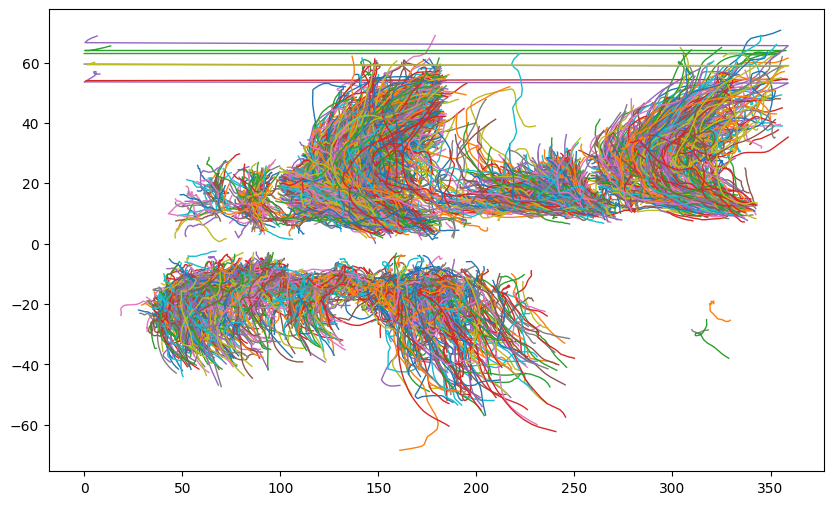

IBTrACS mean= 82.71794871794872
ERA5 mean= 79.43589743589743
ERA5 > 34 kt mean= 65.48717948717949


In [8]:
lat_s = -90
lat_e = 90                        
lon_s = 0
lon_e = 360

year_s = 1980
year_e = 2018

n_year = year_e - year_s + 1
extent = [lon_s, lon_e, lat_s, lat_e]
 
#rd_IB_test (year_s, year_e+10, extent, 34)
tc_count, spd_max = rd_IB(year_s, year_e, extent, 34)
print('IBTrACS mean=', tc_count.mean()) #, spd_max

unique_counts, annual_max = rd_E5_Traj(year_s, year_e, extent, 0) #34*kt2ms)
print('ERA5 mean=', unique_counts.mean())

unique_counts_34, annual_max_34 = rd_E5_Traj(year_s, year_e, extent, 34*kt2ms)
print('ERA5 > 34 kt mean=', unique_counts_34.mean())

- Global

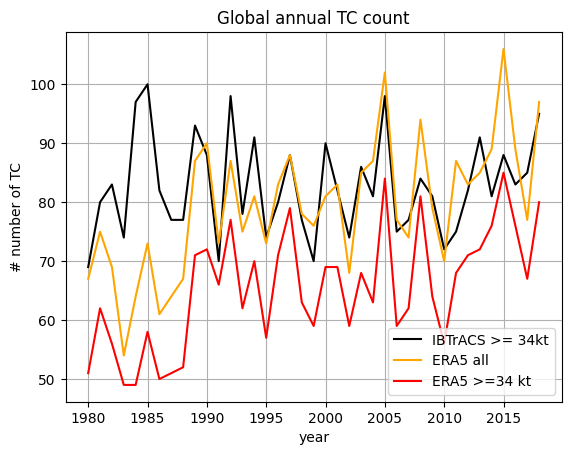

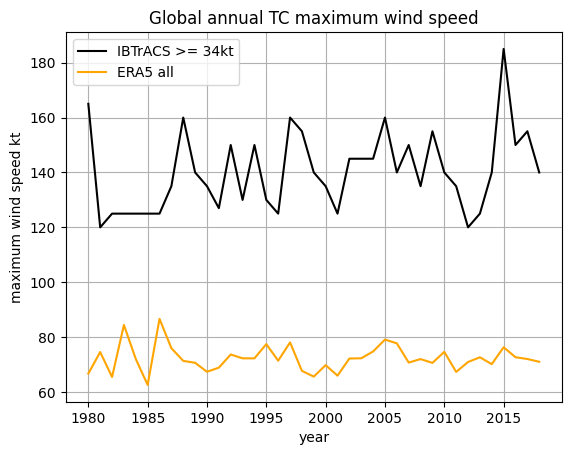

In [6]:
# Global annual TC count
plt.plot(np.arange(year_s, year_e + 1), tc_count, color='black', label='IBTrACS >= 34kt' )
plt.xlabel('year')
plt.ylabel('# number of TC')
plt.title('Global annual TC count')

plt.plot(np.arange(year_s, year_e + 1), unique_counts, color='orange', label='ERA5 all')
plt.plot(np.arange(year_s, year_e + 1), unique_counts_34, color='red', label='ERA5 >=34 kt')
plt.legend() 
plt.grid(True)
plt.show()

# maximum wind speed 
plt.plot(np.arange(year_s, year_e + 1), spd_max, color='black', label='IBTrACS >= 34kt' )
plt.xlabel('year')
plt.ylabel('maximum wind speed kt')
plt.title('Global annual TC maximum wind speed')

plt.plot(np.arange(year_s, year_e + 1), annual_max/kt2ms, color='orange', label='ERA5 all')
  
plt.legend() 
plt.grid(True)
plt.show()

- Australia Buckley Cyclone Regions and New Zealand

 Australia Buckley Cyclone Region 1 [145, 160, -40, -25]


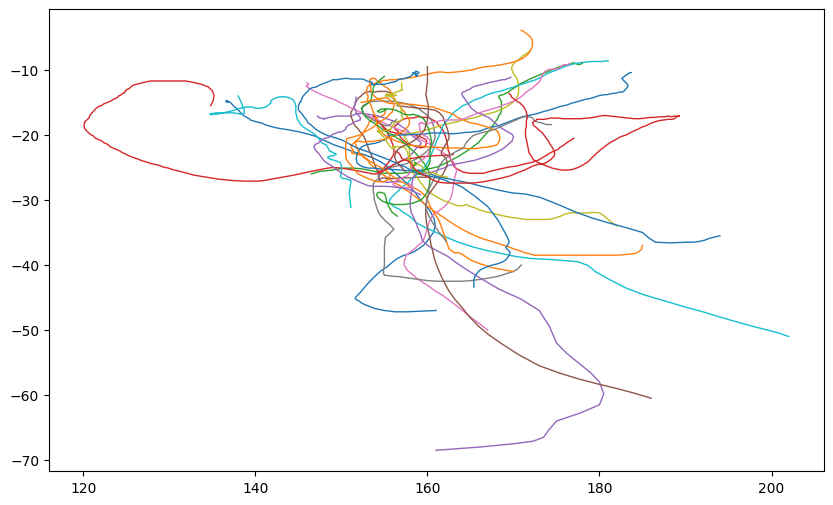

IBTrAC mean= 0.7
ERA5 mean= 1.0
ERA5 > 34 kt mean= 0.8


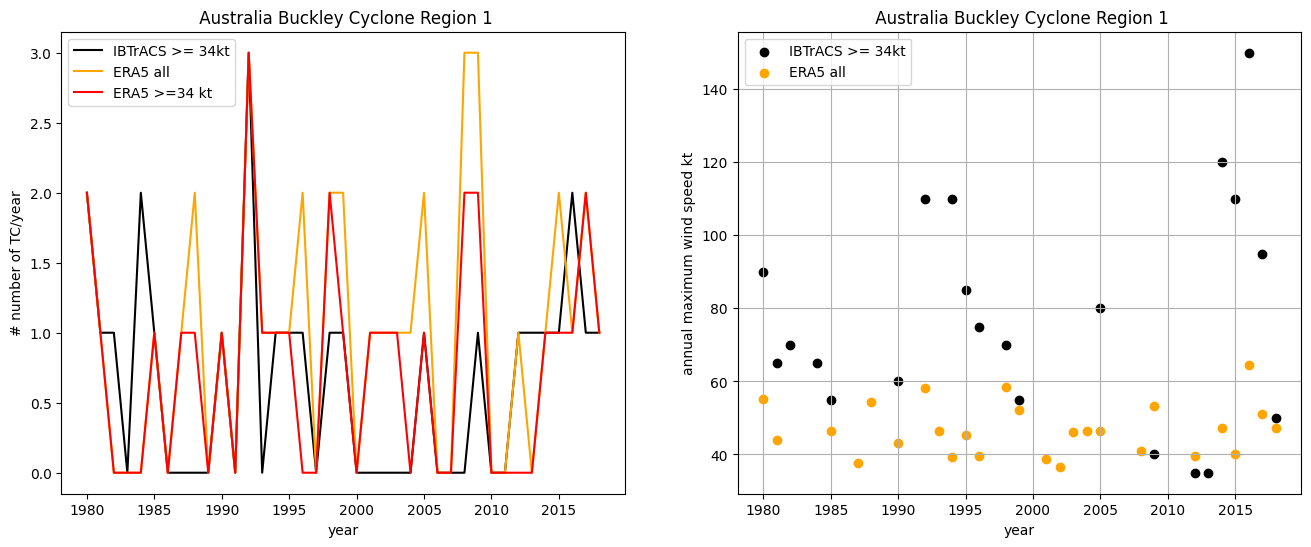

 Australia Buckley Cyclone Region 2 [143, 158, -27, -9]


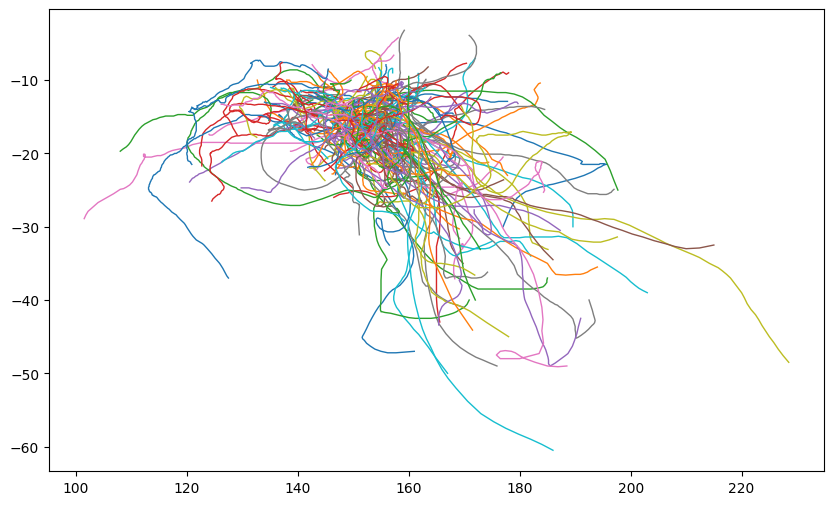

IBTrAC mean= 3.5
ERA5 mean= 3.3
ERA5 > 34 kt mean= 2.0


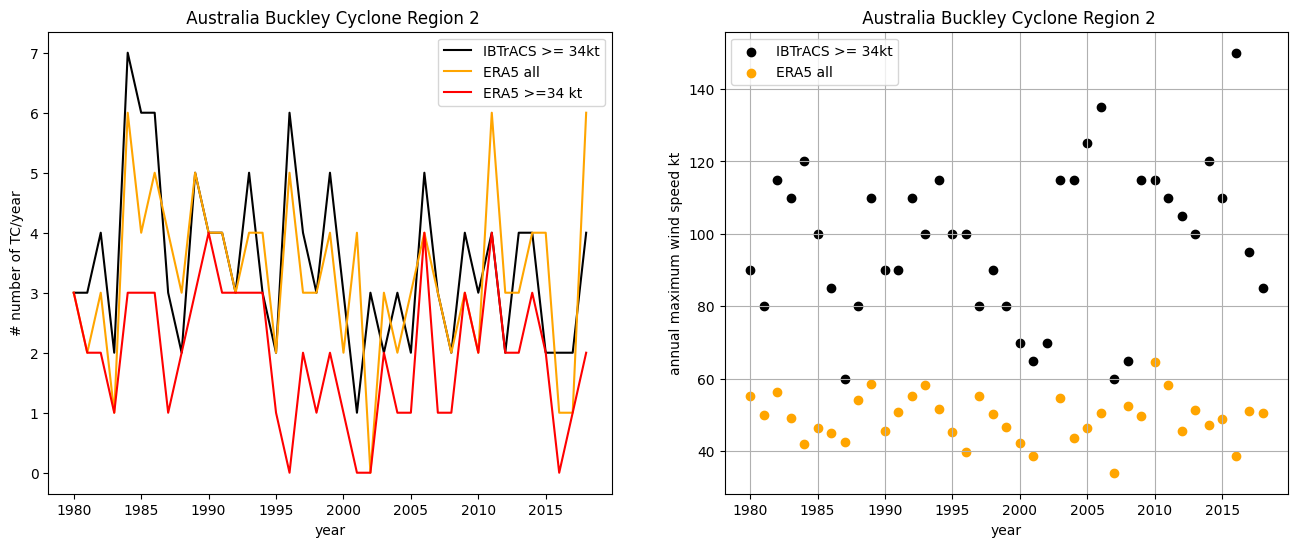

 Australia Buckley Cyclone Region 3 [132, 143, -20, -9]


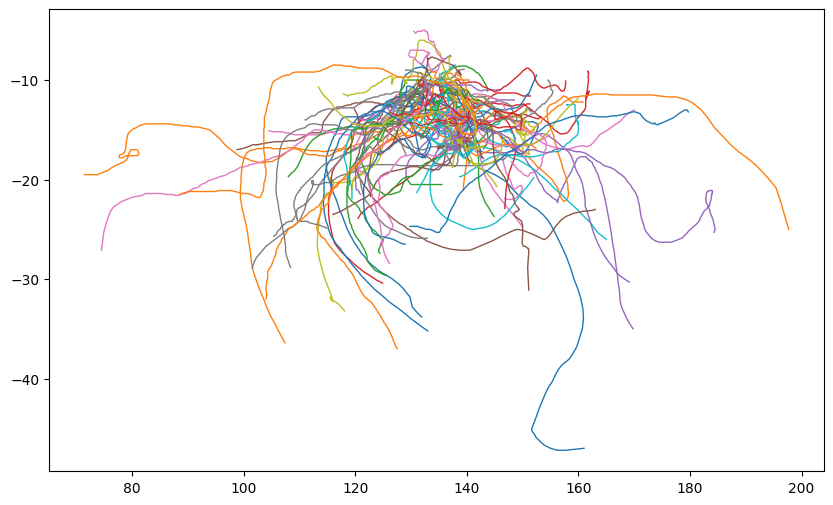

IBTrAC mean= 2.5
ERA5 mean= 2.2
ERA5 > 34 kt mean= 0.9


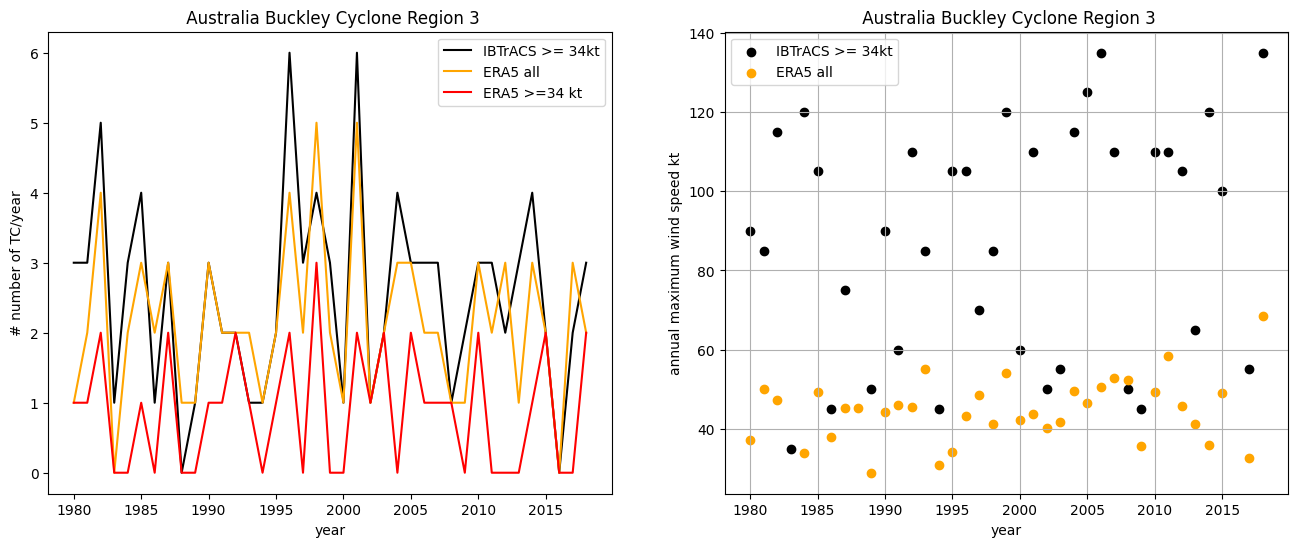

 Australia Buckley Cyclone Region 4 [100, 132, -25, -9]


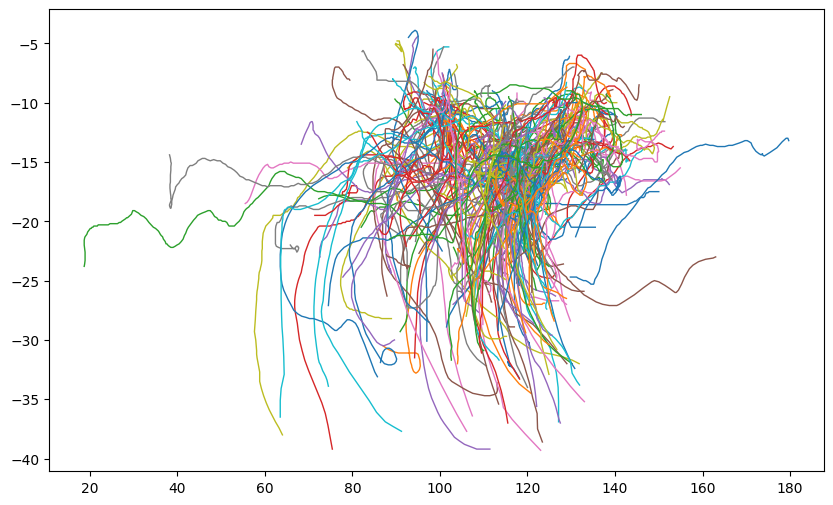

IBTrAC mean= 6.2
ERA5 mean= 5.6
ERA5 > 34 kt mean= 3.7


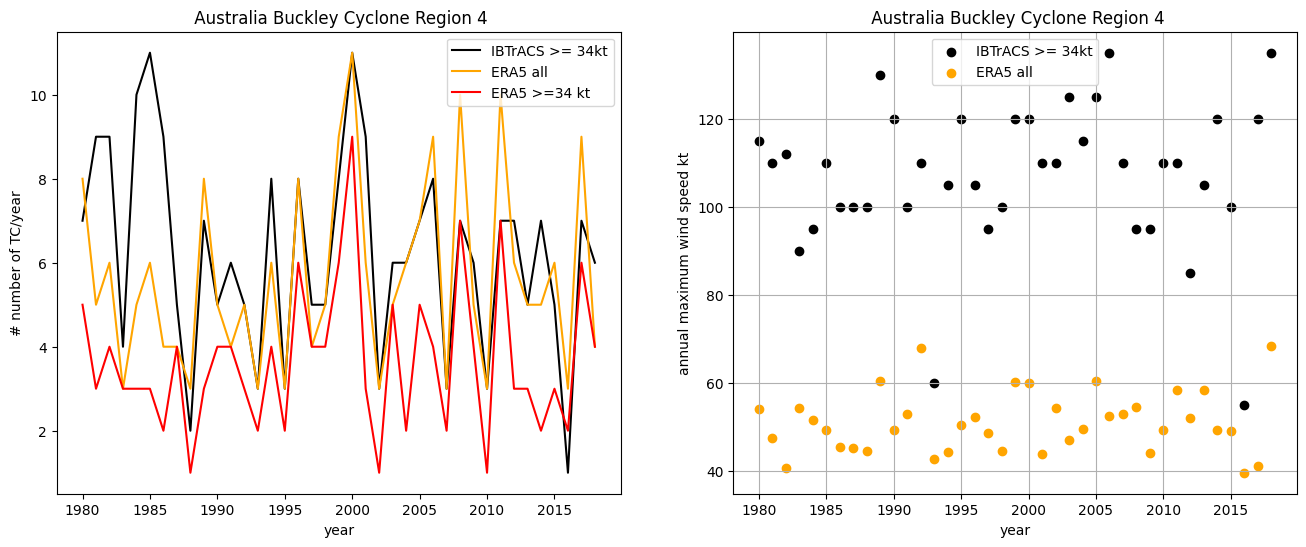

 Australia Buckley Cyclone Region 5 [100, 145, -40, -25]


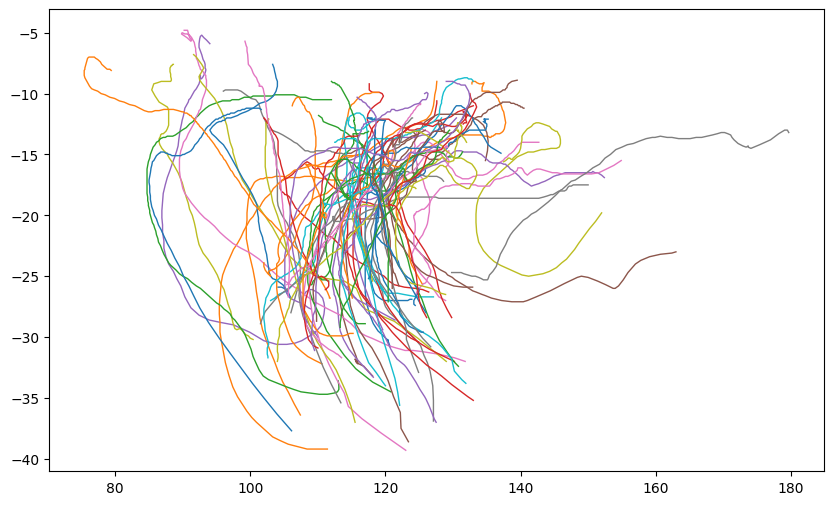

IBTrAC mean= 1.9
ERA5 mean= 1.6
ERA5 > 34 kt mean= 0.7


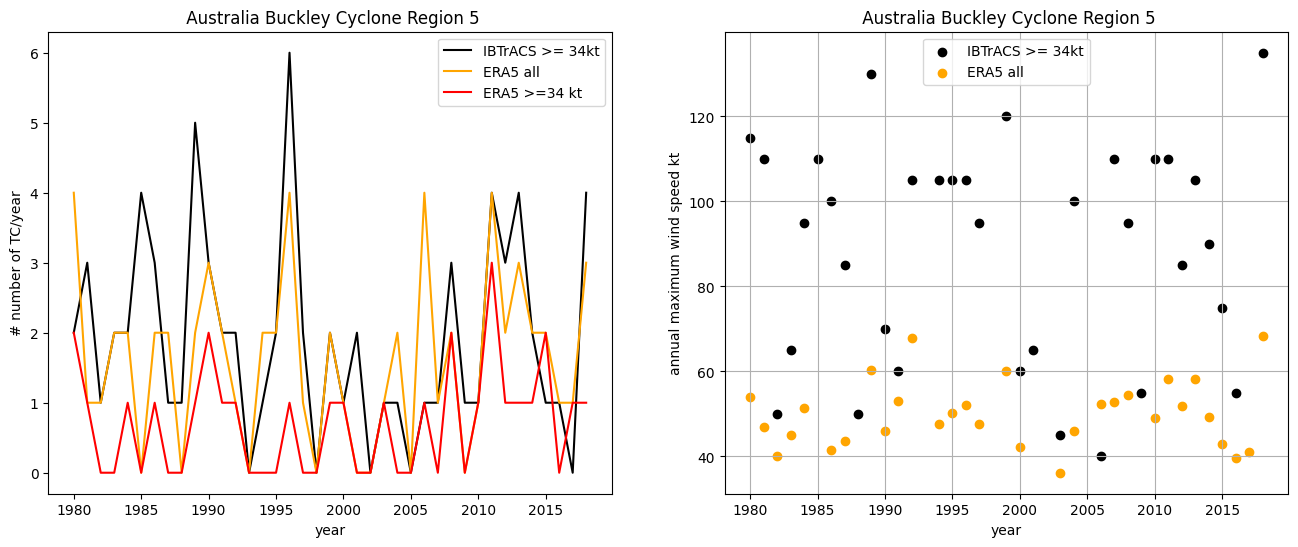

 New Zealand  [163, 183, -48, -30]


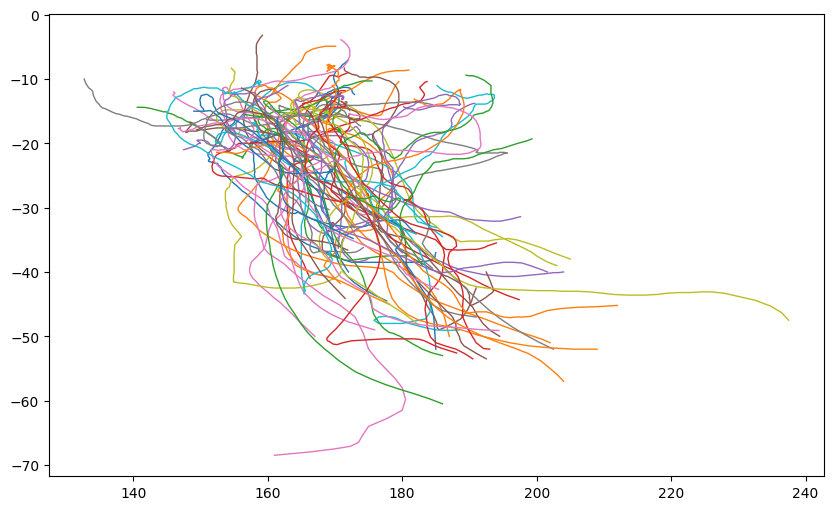

IBTrAC mean= 1.7
ERA5 mean= 2.6
ERA5 > 34 kt mean= 2.1


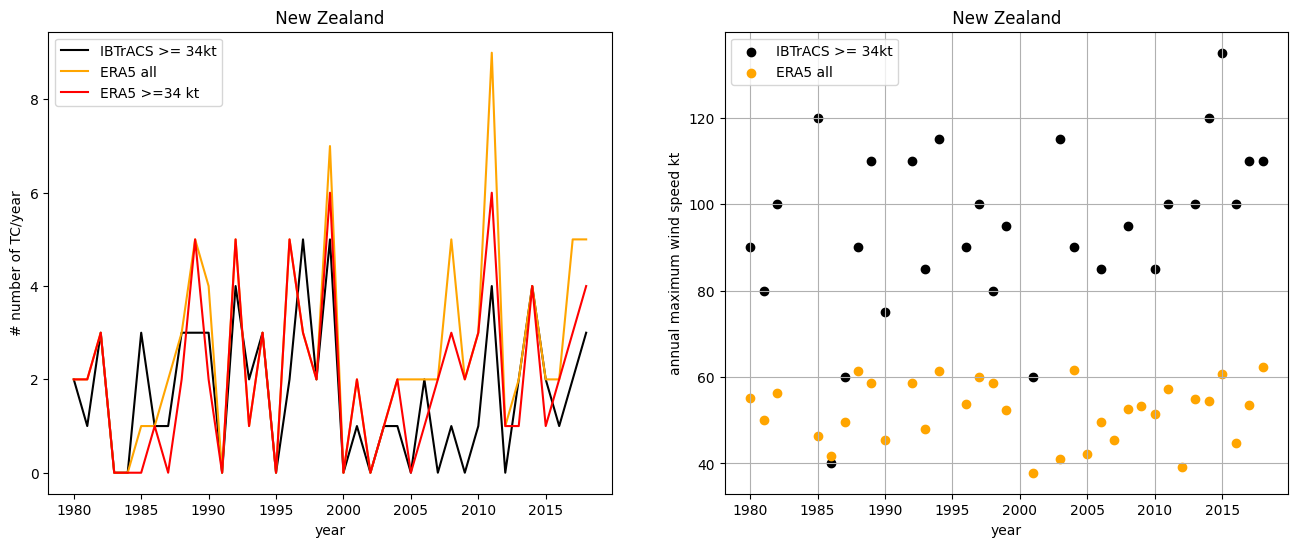

In [10]:
# 5 Buckley Cyclone Regions and New Zealand
region_s = ['BC 1', 'BC 2', 'BC 3', 'BC 4', 'BC 5', 'New Zealand']
color_s = ['lavender', 'mistyrose', 'wheat', 'lightyellow', 'bisque','oldlace']

lat_s_1d = [-40, -27, -20, -25, -40, -48]
lat_e_1d = [-27, -9,  -9,  -9,  -22, -30]
# Use the latitude of 25S as the boundary between the regions on the West side and the East side of Australia.
lat_e_1d = [-25, -9,  -9,  -9,  -25, -30]
lon_s_1d = [145, 143, 132, 100, 100, 163]
lon_e_1d = [160, 158, 143, 132, 145, 183] 

n_region = len(region_s)

# Define full year range
df_all_years = pd.DataFrame({'year': range(year_s, year_e + 1)})
df_all_season = pd.DataFrame({'season': range(year_s, year_e + 1)})
# Create full year range
full_years = range(year_s, year_e + 1)

for nr in range(n_region):
    if nr == n_region - 1:
        title_s = ' New Zealand '
    else:
        title_s = ' Australia Buckley Cyclone Region ' + str(nr + 1)

    lat_s = lat_s_1d[nr]
    lat_e = lat_e_1d[nr]
    lon_s = lon_s_1d[nr]
    lon_e = lon_e_1d[nr]
    lon_cen = (lon_s+lon_e)*0.5
        
    extent = [lon_s, lon_e, lat_s, lat_e]
    print(title_s, extent)
    
    #rd_IB_test (year_s, year_e+10, extent, 34)
    tc_count, spd_max = rd_IB(year_s, year_e, extent, 34)
    
    # To fill in missing years with count 0 in a Pandas Series 
    #spd_max = df_all_years.merge(spd_max, on='year', how='left')  
    #tc_count = tc_count.reindex(full_years, fill_value=0)
    print('IBTrAC mean=', f"{tc_count.mean():.1f}") #, spd_max
    
    unique_counts, annual_max = rd_E5_Traj(year_s, year_e, extent, 0) #34*kt2ms)
    
    # Merge and fill missing with 0
    #unique_counts = df_all_season.merge(unique_counts, on='season', how='left').fillna(0)
    #annual_max = df_all_season.merge(annual_max, on='season', how='left')    
    print('ERA5 mean=', f"{unique_counts.mean():.1f}")

    unique_counts_34, annual_max_34 = rd_E5_Traj(year_s, year_e, extent, 34*kt2ms)
    # Merge and fill missing with 0
    #annual_max_34 = df_all_season.merge(annual_max_34, on='season', how='left').fillna(0)
    #unique_counts_34 = df_all_season.merge(unique_counts_34, on='season', how='left').fillna(0)
    print('ERA5 > 34 kt mean=', f"{unique_counts_34.mean():.1f}")
    #print(tc_count.values)

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 2 rows, 1 column

    axs[0].plot(np.arange(year_s, year_e + 1), tc_count, color='black', label='IBTrACS >= 34kt' )
    axs[0].set_xlabel('year')
    axs[0].set_ylabel('# number of TC/year')
    axs[0].set_title(title_s )

    axs[0].plot(np.arange(year_s, year_e + 1), unique_counts, color='orange', label='ERA5 all')
    axs[0].plot(np.arange(year_s, year_e + 1), unique_counts_34, color='red', label='ERA5 >=34 kt')
    axs[0].legend() 
     
    axs[1].scatter(np.arange(year_s, year_e + 1), spd_max, color='black', label='IBTrACS >= 34kt' )
    axs[1].set_xlabel('year')
    axs[1].set_ylabel('annual maximum wind speed kt')
    axs[1].set_title(title_s)

    axs[1].scatter(np.arange(year_s, year_e + 1), annual_max/kt2ms, color='orange', label='ERA5 all')
  
    axs[1].legend() 
    axs[1].grid(True)
    plt.show()